# Notebook 06 — Explainable AI (SHAP and LIME)

In [1]:
%pip install shap lime transformers torch pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import shap
import lime
from lime.lime_text import LimeTextExplainer
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## Step 1: Load the trained BERT model

In [3]:
MODEL_PATH = '../models/bert_category'

tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

CATEGORY_NAMES = ['Bug Report', 'Feature Request', 'UX Feedback', 'Positive Praise']

print('BERT model loaded')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 19011.28it/s]


BERT model loaded


## Step 2: Prediction function

In [4]:
def predict_proba(texts):
    """
    Returns probability scores for each class.
    Required format for SHAP and LIME.
    """
    if isinstance(texts, str):
        texts = [texts]

    texts = [str(t) for t in texts]

    encodings = tokenizer(
        texts,
        max_length=128,
        padding=True,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    return probs


# Quick test
test_review = 'The app keeps crashing every time I try to open it'
probs = predict_proba([test_review])
print(f'Review: {test_review}')
print(f'Probabilities: {dict(zip(CATEGORY_NAMES, probs[0].round(3)))}')
print(f'Predicted: {CATEGORY_NAMES[probs[0].argmax()]}')

Review: The app keeps crashing every time I try to open it
Probabilities: {'Bug Report': np.float32(0.471), 'Feature Request': np.float32(0.048), 'UX Feedback': np.float32(0.289), 'Positive Praise': np.float32(0.191)}
Predicted: Bug Report


## Step 3: Select the evaluation sample

In [5]:
test_df = pd.read_csv('../data/processed/test.csv')

N_SAMPLES = 20
frac = N_SAMPLES / len(test_df)

sample_df = (
    test_df.groupby('category_label', group_keys=False)
    .sample(frac=frac, random_state=42)
    .reset_index(drop=True)
)

if len(sample_df) > N_SAMPLES:
    sample_df = sample_df.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)
else:
    sample_df = sample_df.reset_index(drop=True)

assert 'category_label' in sample_df.columns, "category_label missing — check test.csv columns"

sample_df['predicted_idx'] = sample_df['clean_text'].apply(lambda t: int(predict_proba([t])[0].argmax()))
sample_df['predicted_label'] = sample_df['predicted_idx'].apply(lambda i: CATEGORY_NAMES[i])

print(f'Evaluation sample: {len(sample_df)} reviews')
print(sample_df['category_name'].value_counts())
print(f"\nModel agreement with true label on this sample: "
      f"{(sample_df['category_label'] == sample_df['predicted_idx']).mean()*100:.1f}%")

Evaluation sample: 20 reviews
category_name
Positive Praise    8
Bug Report         6
UX Feedback        4
Feature Request    2
Name: count, dtype: int64

Model agreement with true label on this sample: 80.0%


## Step 4: LIME explanations

In [6]:
explainer = LimeTextExplainer(class_names=CATEGORY_NAMES)


def explain_with_lime(review_text, pred_idx, num_features=10, num_samples=500):
    """
    Generate a LIME explanation for one review, targeting whatever class the
    model actually predicted (pred_idx) instead of LIME's default (label 1).
    """
    exp = explainer.explain_instance(
        review_text,
        predict_proba,
        labels=(pred_idx,),
        num_features=num_features,
        num_samples=num_samples
    )
    return exp


lime_results = []
print('Running LIME on the evaluation sample (this can take a few minutes)...\n')

for _, row in sample_df.iterrows():
    exp = explain_with_lime(row['clean_text'], row['predicted_idx'])
    top_words = exp.as_list(label=row['predicted_idx'])
    lime_results.append(top_words)

# print the first 3 in full just to sanity-check the output
for i in range(3):
    row = sample_df.iloc[i]
    print(f"Review: {row['clean_text'][:150]}")
    print(f"True: {row['category_name']} | Predicted: {row['predicted_label']}")
    print('Top LIME words:')
    for word, score in lime_results[i][:5]:
        direction = 'FOR' if score > 0 else 'AGAINST'
        print(f'  {word}: {score:.4f} ({direction} prediction)')
    print()

Running LIME on the evaluation sample (this can take a few minutes)...

Review: latest update app keeps crashing?????
True: Bug Report | Predicted: Bug Report
Top LIME words:
  crashing: 0.1150 (FOR prediction)
  update: 0.0455 (FOR prediction)
  keeps: -0.0440 (AGAINST prediction)
  latest: 0.0440 (FOR prediction)
  app: 0.0084 (FOR prediction)

Review: go for it trust me
True: Positive Praise | Predicted: Positive Praise
Top LIME words:
  for: 0.0529 (FOR prediction)
  trust: 0.0528 (FOR prediction)
  it: 0.0427 (FOR prediction)
  go: -0.0357 (AGAINST prediction)
  me: -0.0095 (AGAINST prediction)

Review: i use it for school
True: Positive Praise | Predicted: Positive Praise
Top LIME words:
  use: 0.0833 (FOR prediction)
  it: 0.0694 (FOR prediction)
  i: -0.0258 (AGAINST prediction)
  for: -0.0161 (AGAINST prediction)
  school: -0.0085 (AGAINST prediction)



## Step 5: Save a detailed LIME visualisation

LIME explanation saved to ../reports/lime_explanation_sample.html


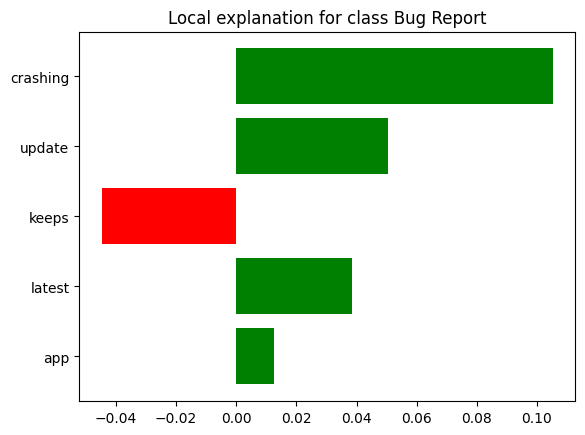

In [7]:
os.makedirs('../reports', exist_ok=True)

sample_row = sample_df.iloc[0]
exp = explain_with_lime(sample_row['clean_text'], sample_row['predicted_idx'])
exp.save_to_file('../reports/lime_explanation_sample.html')
print('LIME explanation saved to ../reports/lime_explanation_sample.html')

fig = exp.as_pyplot_figure(label=sample_row['predicted_idx'])
fig.savefig('../reports/lime_explanation_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: SHAP explanations

In [8]:
masker = shap.maskers.Text(tokenizer)
explainer_shap = shap.Explainer(predict_proba, masker)

print('Computing SHAP values for the evaluation sample (this may take several minutes)...')
shap_values_all = explainer_shap(sample_df['clean_text'].tolist())
print('SHAP values computed for all', len(sample_df), 'reviews')


def top_shap_words(shap_values_row, pred_idx, top_n=5):
    """Extract the top-n words by absolute SHAP contribution for the predicted class."""
    values = shap_values_row.values[:, pred_idx]
    words = shap_values_row.data
    pairs = sorted(zip(words, values), key=lambda x: abs(x[1]), reverse=True)
    return [(w.strip(), float(v)) for w, v in pairs[:top_n] if w.strip()]


shap_results = [
    top_shap_words(shap_values_all[i], sample_df.iloc[i]['predicted_idx'])
    for i in range(len(sample_df))
]

for i in range(3):
    row = sample_df.iloc[i]
    print(f"\nReview: {row['clean_text'][:150]}")
    print(f"Predicted: {row['predicted_label']}")
    print('Top SHAP words:', shap_results[i][:5])

Computing SHAP values for the evaluation sample (this may take several minutes)...


PartitionExplainer explainer: 21it [00:27,  2.33s/it]                        

SHAP values computed for all 20 reviews

Review: latest update app keeps crashing?????
Predicted: Bug Report
Top SHAP words: [('crashing', 0.10055469814687967), ('update', 0.09992765868082643), ('app', 0.07341333711519837), ('keeps', 0.04972210433334112), ('latest', 0.04930098541080952)]

Review: go for it trust me
Predicted: Positive Praise
Top SHAP words: [('trust', 0.15855354629456997), ('for', 0.09840208292007446), ('it', 0.08434710651636124), ('go', 0.07640222273766994), ('me', 0.03133237175643444)]

Review: i use it for school
Predicted: Positive Praise
Top SHAP words: [('use', 0.16645042598247528), ('it', 0.08123279735445976), ('i', 0.07213634252548218), ('for', 0.051301343366503716), ('school', 0.016285492107272148)]


## Step 7: SHAP visualisation (detailed, single review)

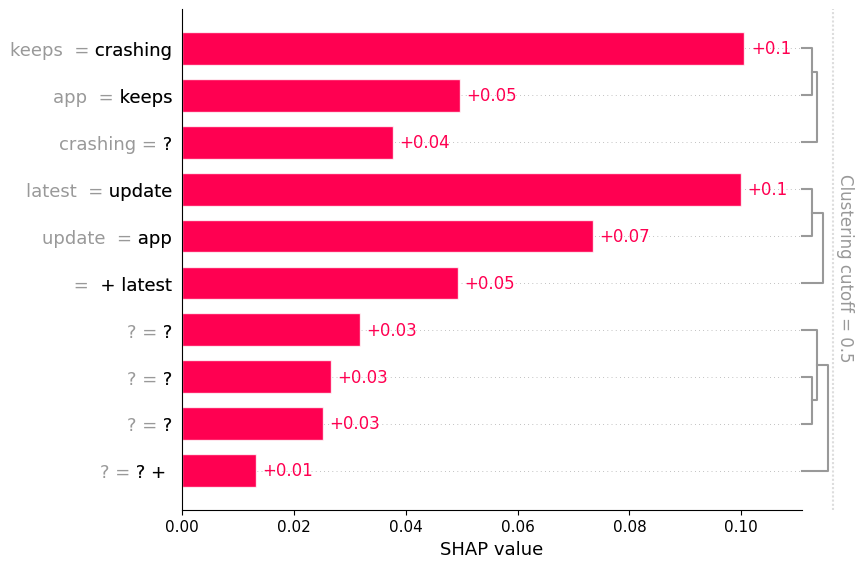

<Figure size 640x480 with 0 Axes>

SHAP plots saved to ../reports/


In [9]:
pred_class_idx = int(sample_df.iloc[0]['predicted_idx'])

shap.plots.text(shap_values_all[0, :, pred_class_idx])

shap.plots.bar(shap_values_all[0, :, pred_class_idx])
plt.savefig('../reports/shap_bar_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print('SHAP plots saved to ../reports/')

## Step 8: SHAP vs LIME agreement (RQ2)

In [10]:
import re

def normalise(word):
    return re.sub(r'[^a-z0-9]', '', word.lower().replace('##', ''))


agreement_rows = []
for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    shap_words = {normalise(w) for w, _ in shap_results[i]}
    lime_words = {normalise(w) for w, _ in lime_results[i]}
    shap_words.discard('')
    lime_words.discard('')

    overlap = len(shap_words & lime_words)
    denom = min(len(shap_words), len(lime_words)) or 1
    overlap_coef = overlap / denom

    agreement_rows.append({
        'review_id': row.get('review_id', i),
        'true_category': row['category_name'],
        'predicted_category': row['predicted_label'],
        'shap_top_words': ', '.join(sorted(shap_words)),
        'lime_top_words': ', '.join(sorted(lime_words)),
        'shared_words': ', '.join(sorted(shap_words & lime_words)),
        'overlap_coefficient': round(overlap_coef, 3)
    })

agreement_df = pd.DataFrame(agreement_rows)
print('=== SHAP vs LIME Agreement — per review ===\n')
print(agreement_df[['true_category', 'predicted_category', 'shared_words', 'overlap_coefficient']].to_string(index=False))

mean_overlap = agreement_df['overlap_coefficient'].mean()
print(f'\n=== RQ2 answer (this sample) ===')
print(f'Mean SHAP-LIME overlap coefficient across {len(agreement_df)} reviews: {mean_overlap:.3f}')
print('(0 = no agreement, 1 = identical top-5 word sets)')

print('\nAgreement by category:')
print(agreement_df.groupby('true_category')['overlap_coefficient'].mean().round(3))

os.makedirs('../reports', exist_ok=True)
agreement_df.to_csv('../reports/shap_lime_agreement.csv', index=False)
print('\nSaved to ../reports/shap_lime_agreement.csv — cite this table directly in the RQ2 section')

=== SHAP vs LIME Agreement — per review ===

  true_category predicted_category                            shared_words  overlap_coefficient
     Bug Report         Bug Report    app, crashing, keeps, latest, update                1.000
Positive Praise    Positive Praise                  for, go, it, me, trust                1.000
Positive Praise    Positive Praise                 for, i, it, school, use                1.000
     Bug Report    Feature Request           email, is, option, there, via                1.000
Feature Request         Bug Report              don, option, see, still, t                1.000
     Bug Report         Bug Report                            payment, try                0.400
    UX Feedback        UX Feedback                    most, of, pay, sadly                0.800
     Bug Report         Bug Report                     app, bugs, fix, its                0.800
Positive Praise        UX Feedback                         but, review, to                0

## Step 9: Coherence check (target: 80%)

In [14]:
coherence_template = agreement_df[['review_id', 'true_category', 'predicted_category',
                                     'shap_top_words', 'lime_top_words']].copy()
coherence_template['review_text'] = sample_df['clean_text'].str[:200].values
coherence_template['coherent_Y_N'] = ''
coherence_template['notes'] = ''

coherence_template.to_csv('../reports/coherence_assessment_template.csv', index=False)
print('Template saved to ../reports/coherence_assessment_template.csv')
print('Open this file, fill in coherent_Y_N for each of the 20 rows, then compute:')
print('  pct_coherent = (coherent_Y_N == "Y").mean() * 100')
print('and report that percentage against the >= 80% success criterion in the results chapter.')

Template saved to ../reports/coherence_assessment_template.csv
Open this file, fill in coherent_Y_N for each of the 20 rows, then compute:
  pct_coherent = (coherent_Y_N == "Y").mean() * 100
and report that percentage against the >= 80% success criterion in the results chapter.
